2023-10-31 18:26:34,513 - INFO - tvb_multiscale.tvb_nest.config - Configuring NEST path...
2023-10-31 18:26:34,513 - INFO - tvb_multiscale.tvb_nest.config - Configuring NEST path...
2023-10-31 18:26:34,515 - INFO - tvb_multiscale.tvb_nest.config - NEST_INSTALL_DIR: /home/docker/env/neurosci/nest_build
2023-10-31 18:26:34,515 - INFO - tvb_multiscale.tvb_nest.config - NEST_INSTALL_DIR: /home/docker/env/neurosci/nest_build
2023-10-31 18:26:34,517 - INFO - tvb_multiscale.tvb_nest.config - NEST_DATA_DIR: /home/docker/env/neurosci/nest_build/share/nest
2023-10-31 18:26:34,517 - INFO - tvb_multiscale.tvb_nest.config - NEST_DATA_DIR: /home/docker/env/neurosci/nest_build/share/nest
2023-10-31 18:26:34,518 - INFO - tvb_multiscale.tvb_nest.config - NEST_DOC_DIR: /home/docker/env/neurosci/nest_build/share/doc/nest
2023-10-31 18:26:34,518 - INFO - tvb_multiscale.tvb_nest.config - NEST_DOC_DIR: /home/docker/env/neurosci/nest_build/share/doc/nest
2023-10-31 18:26:34,520 - INFO - tvb_multiscale.tvb_ne

<Figure size 432x288 with 0 Axes>

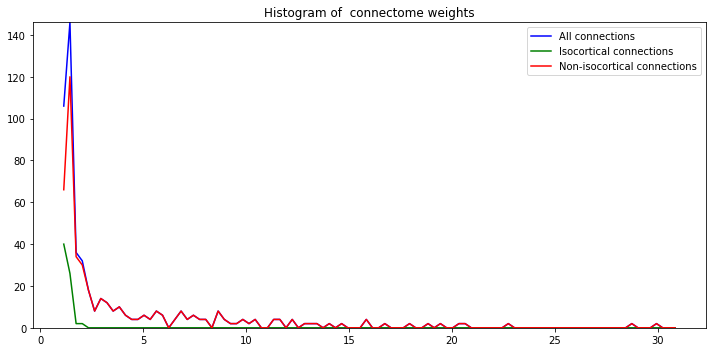

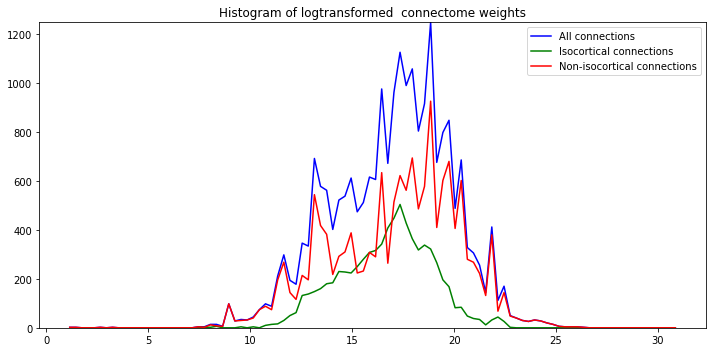

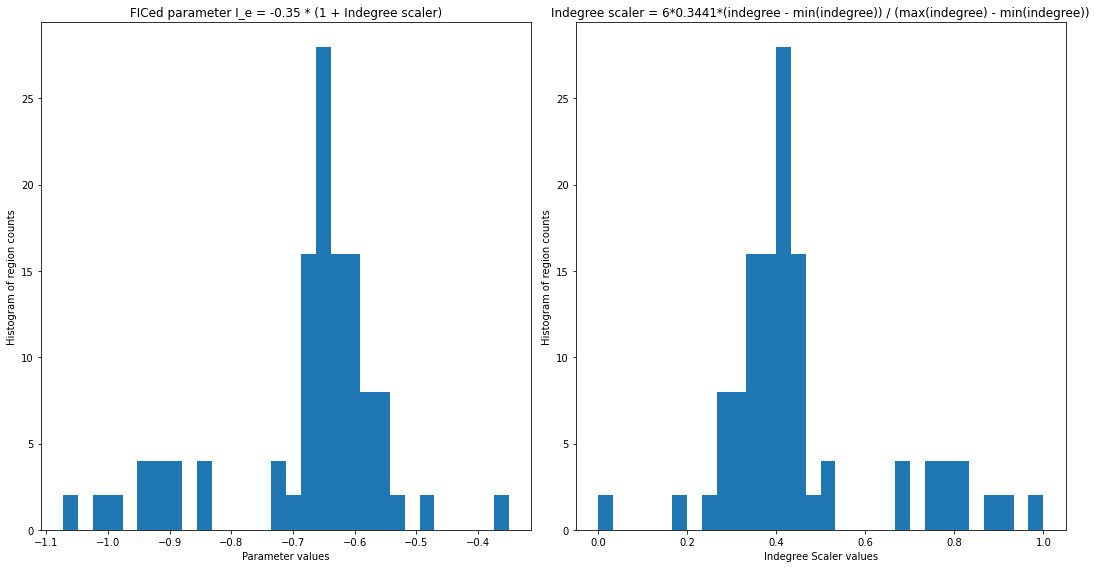

Applying FIC for parameter w_ie: G * FIC * (1.0-FIC_SPLIT) = 6 * 1.11 * 0.69 = 4.5954!


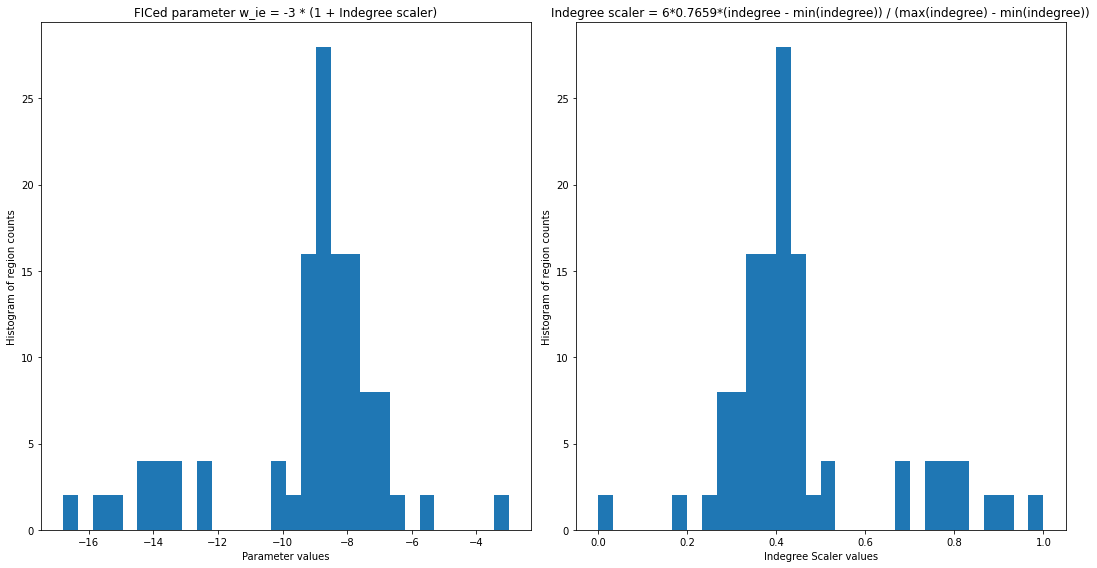

2023-10-31 18:26:36,892 - WARNING - tvb_multiscale.core.tvb.cosimulator.cosimulator_serial - There are no existing connections (i.e., with nonzero weights)!
Setting minimum delay to 1 integrator time step = 0.1!.
2023-10-31 18:26:36,896 - WARNING - tvb_multiscale.core.tvb.cosimulator.cosimulator_serial - Current step is not 0 upon configuration!
Setting it to 0. Initial condition might be affected!
Current step is not 0 upon configuration!
Setting it to 0. Initial condition might be affected!
CoSimulatorSerial (
  title ............................... 'CoSimulatorSerial gid: e9355361-2f50-46d0-9016-1a699ff3fac5'
  Type ................................ 'CoSimulatorSerial'
  model ............................... WilsonCowanThalamoCortical gid: 8f0d3ff3-6dba-442b-b26b-d0c02090fecc
  output_interfaces ................... None
  input_interfaces .................... None
  out_proxy_inds ...................... --------------------
  shape ............................... (0,)
  dtype .......

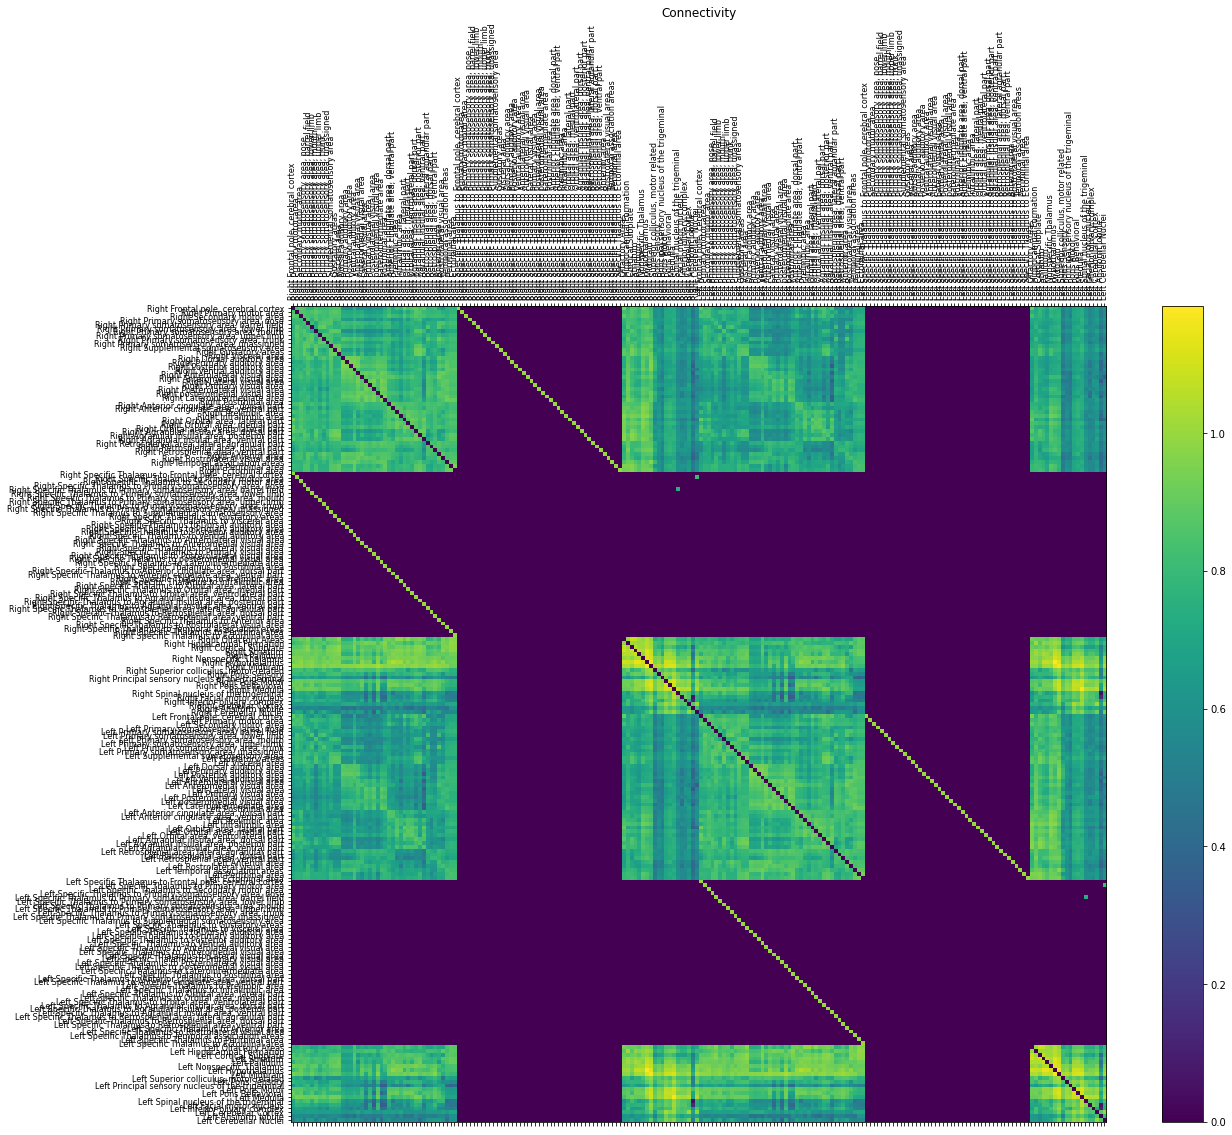

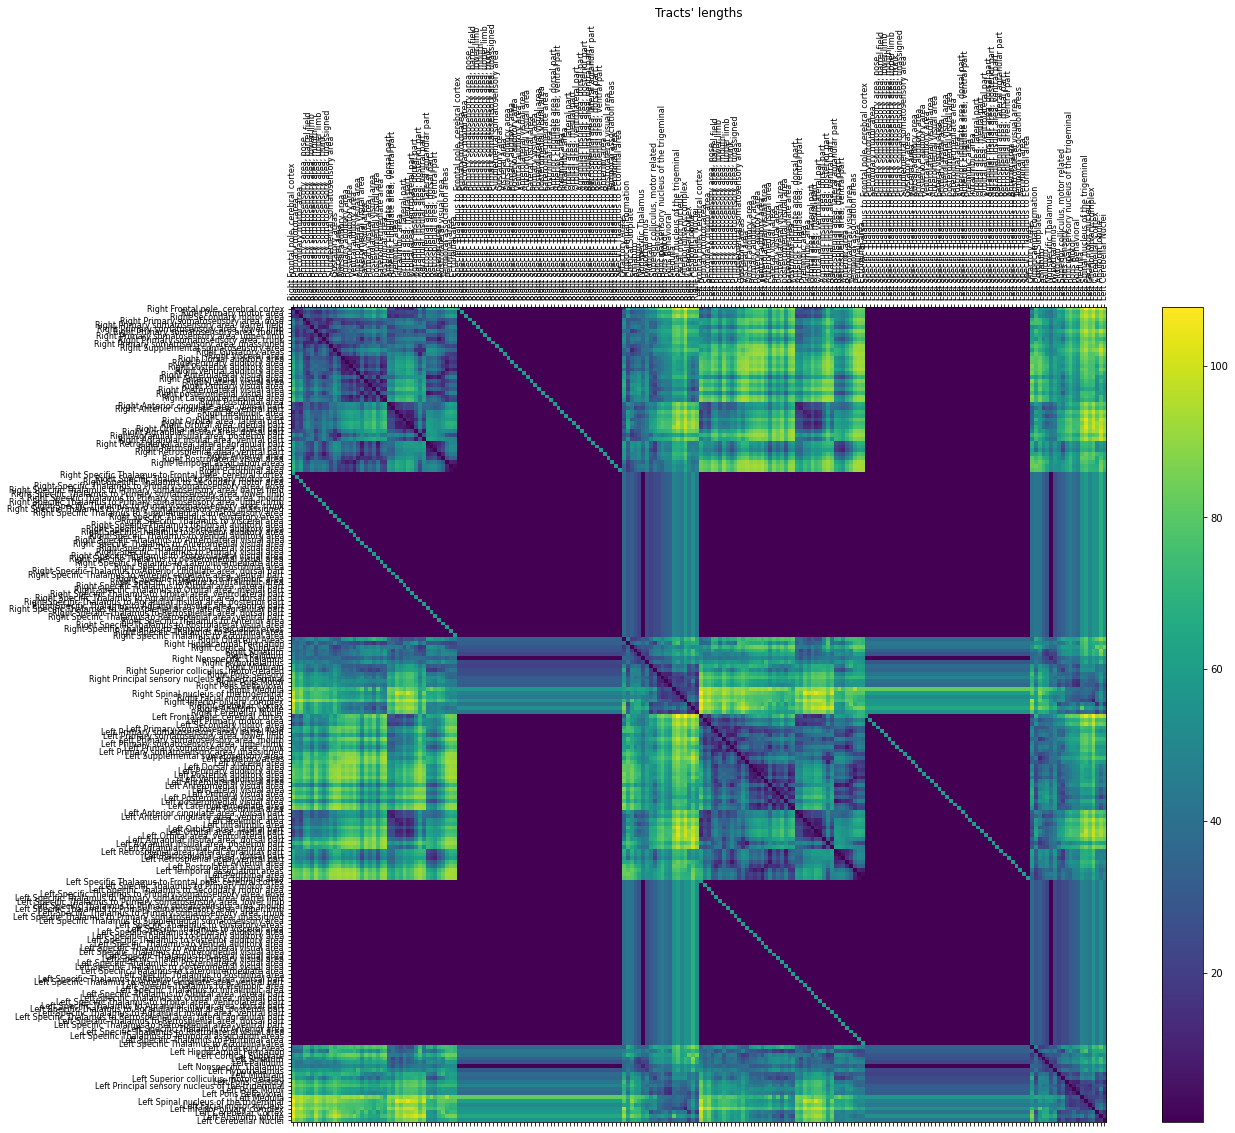


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: HEAD@c545255f7
 Built: May 18 2022 09:50:55

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

2023-10-31 18:26:58,576 - WARNING - tvb_multiscale.core.neotraits - Field seems mutable and has a default value. Consider using a lambda as a value factory 
   attribute tvb_multiscale.tvb_nest.nest_models.node._NESTNodeCollection._nodes = Attr(field_type=(<class 'nest.lib.hl_api_types.NodeCollection'>, <class 'tvb_multiscale.tvb_nest.nest_models.server_client.node_collection.NodeCollection'>), default=NodeCollection(<empty>), required=False)
2023-10-31 18:26:58,576 - WARNING - tvb_multiscale.core.neotraits - Field seems mutable and has a default value. Consider using a lambda as a value factory 
   attribute tvb_multiscale.tvb_nest.nest_models.node._NE

In [1]:
from scripts.tvb_nest_script import *
from tvb_multiscale.core.plot.plotter import Plotter
from tvb.contrib.scripts.datatypes.time_series_xarray import TimeSeriesRegion as TimeSeriesXarray

from scripts.nest_script import *        #build_NEST_network, plot_nest_results


# Assuming:
# DEFAULT_ARGS = {'G': 6.0, 'STIMULUS': 0.1,
#                 'I_e': -0.35, 'I_s': 0.085,
#                 'w_ie': -3.0, 'w_rs': -2.0,
#                 'CONN_LOG': True, 'FIC': 1.11,  'FIC_SPLIT': 0.31,  #'fit',
#                 'PRIORS_DIST': 'uniform',
#                 'output_folder': "", 'verbose': 1, 'plot_flag': True}

# # TVB - NEST interface parameters:
# config.TRANSIENT_RATIO =0.25
# config.MOSSY_MAX_RATE = 122.0  # Hz
# config.w_TVB_to_NEST = 0.04375

seed = 10
test_name = 'cosim'              # 'cosim', 'tvb-only', 'cerebOFF'
if test_name=='cosim':
    COMPUTE_REF = False          # True if you want to run TVB-only
    CEREB_OFF = False
elif test_name=='tvb-only':
    COMPUTE_REF = True
    CEREB_OFF = False
elif test_name == 'cerebOFF':
    COMPUTE_REF = True
    CEREB_OFF = True

resfilename = "results_%s_noise_seed_%d" % (test_name, seed)
path = os.path.join(os.getcwd(), resfilename)
# Get configuration
config, plotter = configure(output_folder=path, verbose=2)
config.SIMULATION_LENGTH = 30000
config.RANDOM_SEED_TVB = seed
config.RANDOM_SEED_NEST = seed

# Load and prepare connectome and connectivity with all possible normalizations:
connectome, major_structs_labels, voxel_count, inds, maps = prepare_connectome(config, plotter=plotter)
connectivity = build_connectivity(connectome, inds, config)

# # Scale up connections from principal sensory trigeminal nucleus to ansiform lobule
# reg1='Left Ansiform lobule'
# reg2='Right Ansiform lobule'
# reg3 = 'Left Principal sensory nucleus of the trigeminal'
# reg4 = 'Right Principal sensory nucleus of the trigeminal'
# reg5 = 'Left Spinal nucleus of the trigeminal'
# reg6 = 'Right Spinal nucleus of the trigeminal'
# #find the indices in region labels of these strings
# iR1 = np.where([reg1 in reg for reg in connectivity.region_labels])[0]
# iR2 = np.where([reg2 in reg for reg in connectivity.region_labels])[0]
# iR3 = np.where([reg3 in reg for reg in connectivity.region_labels])[0]
# iR4 = np.where([reg4 in reg for reg in connectivity.region_labels])[0]
# iR5 = np.where([reg5 in reg for reg in connectivity.region_labels])[0]
# iR6 = np.where([reg6 in reg for reg in connectivity.region_labels])[0]
#
# pathway_gain = 1
# '''# PST to AN
# connectivity.weights[iR1, iR3] *= pathway_gain
# connectivity.weights[iR1, iR4] *= pathway_gain
# connectivity.weights[iR2, iR3] *= pathway_gain
# connectivity.weights[iR2, iR4] *= pathway_gain
# # SNT to PST
# connectivity.weights[iR3, iR5] *= pathway_gain
# connectivity.weights[iR3, iR6] *= pathway_gain
# connectivity.weights[iR4, iR5] *= pathway_gain
# connectivity.weights[iR4, iR6] *= pathway_gain
# '''
# # SNT to AN
# connectivity.weights[iR1, iR5] *= pathway_gain
# connectivity.weights[iR1, iR6] *= pathway_gain
# connectivity.weights[iR2, iR5] *= pathway_gain
# connectivity.weights[iR2, iR6] *= pathway_gain

# # To have the full sensory whisking pathway
# reg7 = 'Left Primary somatosensory area, barrel field'
# reg8 = 'Right Primary somatosensory area, barrel field'
# iR7 = np.where([reg7 in reg for reg in connectivity.region_labels])[0]
# iR8 = np.where([reg8 in reg for reg in connectivity.region_labels])[0]
# # S1 to PST
# connectivity.weights[iR3, iR7] *= pathway_gain
# connectivity.weights[iR3, iR8] *= pathway_gain
# connectivity.weights[iR4, iR7] *= pathway_gain
# connectivity.weights[iR4, iR8] *= pathway_gain
# # SNT to S1
# connectivity.weights[iR7, iR5] *= pathway_gain
# connectivity.weights[iR7, iR6] *= pathway_gain
# connectivity.weights[iR8, iR5] *= pathway_gain
# connectivity.weights[iR8, iR6] *= pathway_gain


# Put cereb weights to 0 if CEREB_OFF
if CEREB_OFF:
    #reg1='Cerebell*'
    reg1='Left Cerebellar Cortex'
    reg2='Left Cerebellar Nuclei'
    reg3='Left Ansiform lobule'
    reg4='Left Interposed nucleus'
    reg5='Right Cerebellar Cortex'
    reg6='Right Cerebellar Nuclei'
    reg7='Right Ansiform lobule'
    reg8='Right Interposed nucleus'
    #find the indices in region labels of these strings
    iR1 = np.where([reg1 in reg for reg in connectivity.region_labels])[0]
    iR2 = np.where([reg2 in reg for reg in connectivity.region_labels])[0]
    iR3 = np.where([reg3 in reg for reg in connectivity.region_labels])[0]
    iR4 = np.where([reg4 in reg for reg in connectivity.region_labels])[0]
    iR5 = np.where([reg5 in reg for reg in connectivity.region_labels])[0]
    iR6 = np.where([reg6 in reg for reg in connectivity.region_labels])[0]
    iR7 = np.where([reg7 in reg for reg in connectivity.region_labels])[0]
    iR8 = np.where([reg8 in reg for reg in connectivity.region_labels])[0]
    # for reg1, reg2, sc in config.BRAIN_CONNECTIONS_TO_SCALE:
    #     iR1 = np.where([reg in reg1 for reg in connectivity.region_labels])[0]
    #     iR2 = np.where([reg in reg2 for reg in connectivity.region_labels])[0]
    #     connectivity.weights[iR1, iR2] *= 0
    #iR1
    connectivity.weights.shape
    for i in [iR1, iR2, iR3, iR4, iR5, iR6, iR7, iR8]:
        connectivity.weights[i,:]=0
        connectivity.weights[:,i]=0
                        # , iR2, iR3, iR4, iR5, iR6, iR7, iR8] = 0
    connectivity.weights[iR1,:]


# Prepare model
model = build_model(connectivity.number_of_regions, inds, maps, config)

# Prepare simulator
simulator = build_simulator(connectivity, model, inds, maps, config, plotter=plotter)

if COMPUTE_REF:
    # Run simulation and get results for reference values
    results, transient = simulate(simulator, config)
else:
    # Build TVB-NEST interfaces
    nest_network, nest_nodes_inds, neuron_models, neuron_number = build_NEST_network(config)
    simulator, nest_network = build_tvb_nest_interfaces(simulator, nest_network, nest_nodes_inds, config)
    # Simulate TVB-NEST model
    results, transient, simulator, nest_network = simulate_tvb_nest(simulator, nest_network, config)
        
print(results)
       

        
# Target values: ansilob=-0.3263, interposed=-0.3209, oliv=-0.3284


In [2]:
# Compute coherence
transient = config.TRANSIENT_RATIO * config.SIMULATION_LENGTH
if config.RAW_PERIOD > config.DEFAULT_DT:
    transient = (transient // config.RAW_PERIOD) * config.RAW_PERIOD + config.RAW_PERIOD/2

results = plot_tvb(transient, inds,
                   results=results, simulator=simulator, plotter=plotter, config=config, write_files=True)

[(array([-0.5,  0.5,  1.5,  2.5,  3.5]), array([[[[-0.3339213 ],
         [-0.32343223],
         [-0.31019527],
         ...,
         [-0.28246611],
         [-0.36403794],
         [-0.32975453]],

        [[        nan],
         [        nan],
         [        nan],
         ...,
         [        nan],
         [        nan],
         [        nan]],

        [[        nan],
         [        nan],
         [        nan],
         ...,
         [        nan],
         [        nan],
         [        nan]]],


       [[[-0.36381608],
         [-0.36763851],
         [-0.15301841],
         ...,
         [-0.32820705],
         [-0.49517188],
         [-0.49517188]],

        [[-0.37003065],
         [-0.34769537],
         [-0.30913272],
         ...,
         [-0.18893085],
         [        nan],
         [        nan]],

        [[ 0.73923632],
         [ 0.72702861],
         [ 0.76756796],
         ...,
         [-0.78828795],
         [        nan],
         [        nan]]

/home/docker/packages/tvb-multiscale/rising_net/outputs/tuned_interfaces_max_rate_122_rnd10_cosim/results_30sec_CORRECT_rnd10_cosim.pickle


/home/docker/packages/tvb-multiscale/rising_net/scripts/tvb_script.py:744: UserWarning:H5Writer cannot be imported! Probably you haven't installed tvb_framework.
/home/docker/packages/tvb-multiscale/rising_net/scripts/tvb_script.py:814: UserWarning:Failed to construct BOLD time series with error!:
'TimeSeriesRegion' object has no attribute 'sample_period'


Pickle-dumping source_ts to /home/docker/packages/tvb-multiscale/rising_net/outputs/tuned_interfaces_max_rate_122_rnd10_cosim/res/source_ts.pkl!
Raw ts:
TimeSeriesRegion (
  Dimensions .......... ['Time', 'State Variable', 'Region', 'Neurons']
  Length .............. 5
  Region Mapping ...... None
  Region Mapping Volume  None
  Sample period ....... 1.0
  Source Connectivity . Connectivity gid: 03d5546f-435e-4f86-80ee-e158b57d3209
  Time units .......... ms
  Time-series name .... Region Time Series
  Time-series type .... TimeSeriesRegion
  [min, median, max] .. [nan, nan, nan]
  dtype ............... float64
  has NaN ............. True
  shape ............... (5, 3, 212, 1)
)
Pickle-dumping BOLD TVB monitor output to /home/docker/packages/tvb-multiscale/rising_net/outputs/tuned_interfaces_max_rate_122_rnd10_cosim/res/bold_ts.pkl!


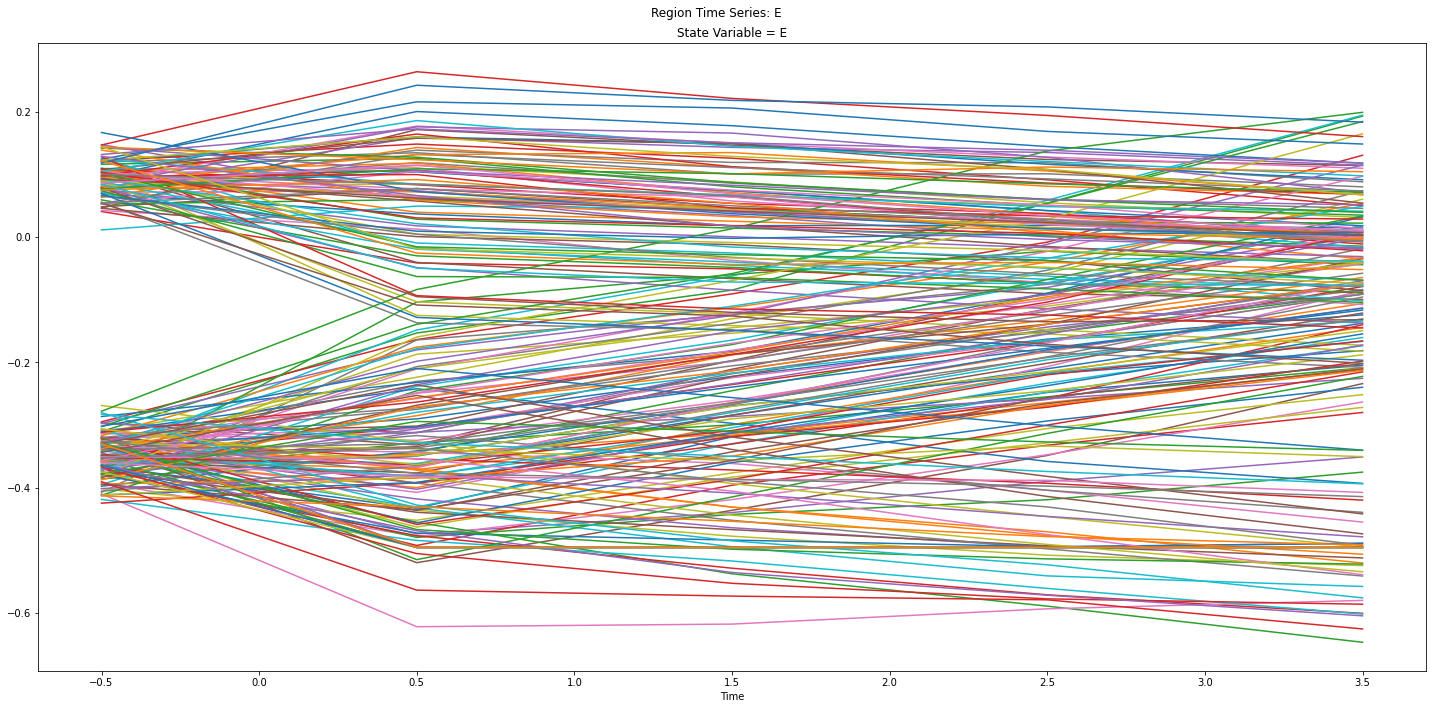

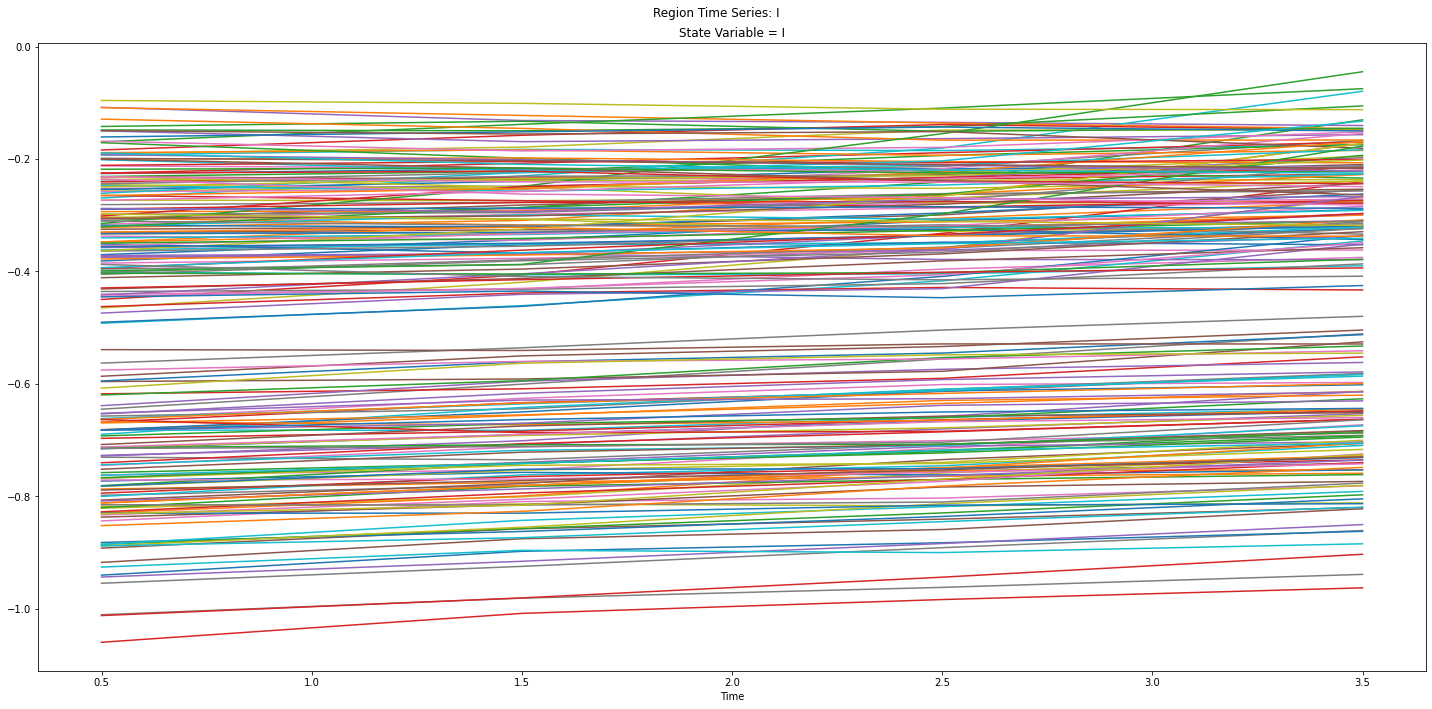

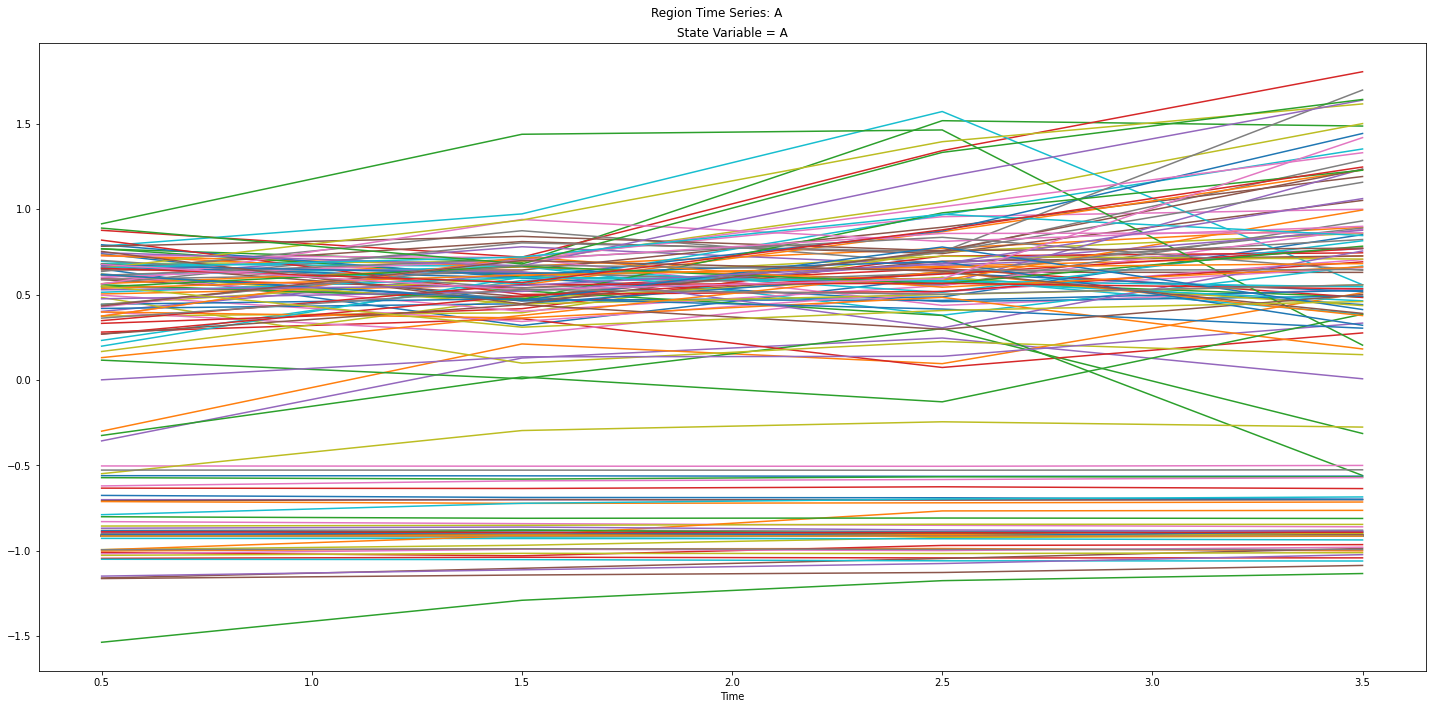

2023-10-31 18:29:30,776 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:30,778 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!
2023-10-31 18:29:30,783 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:30,785 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


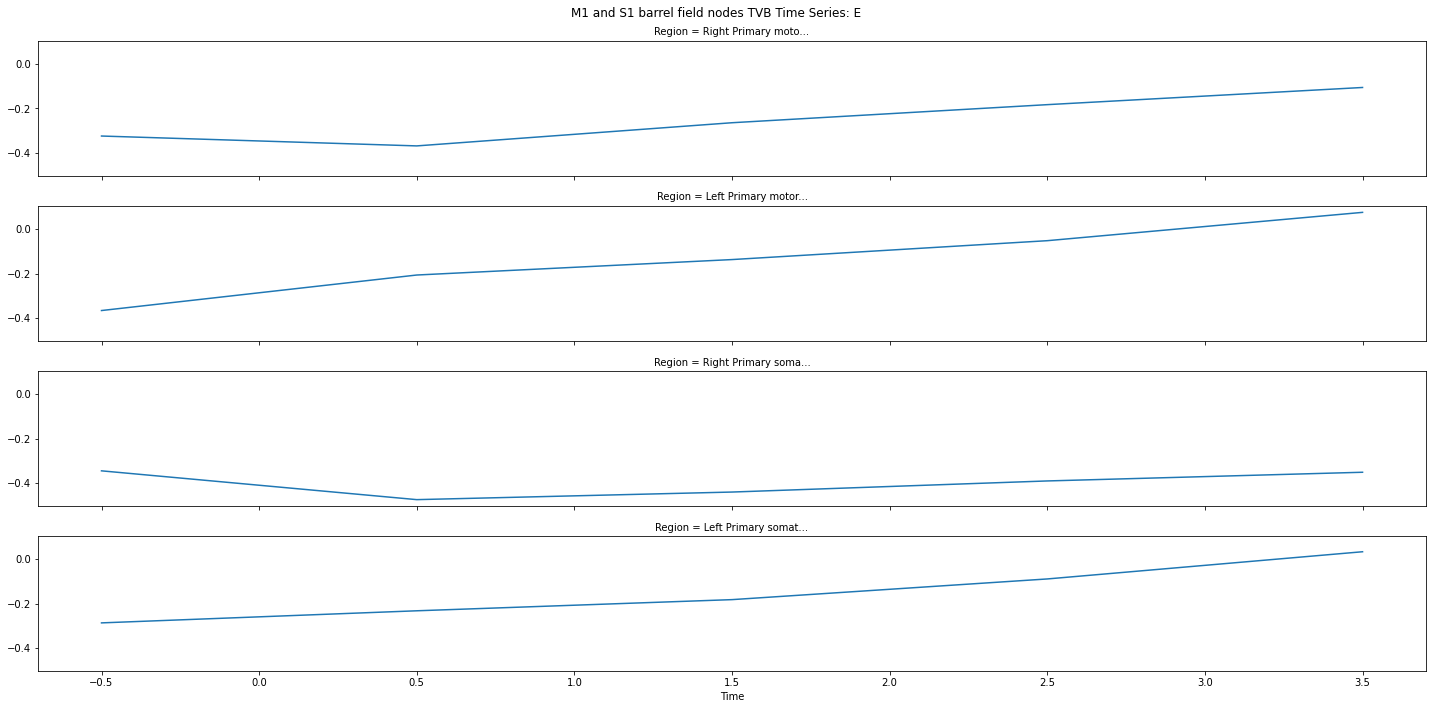

2023-10-31 18:29:32,476 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:32,477 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


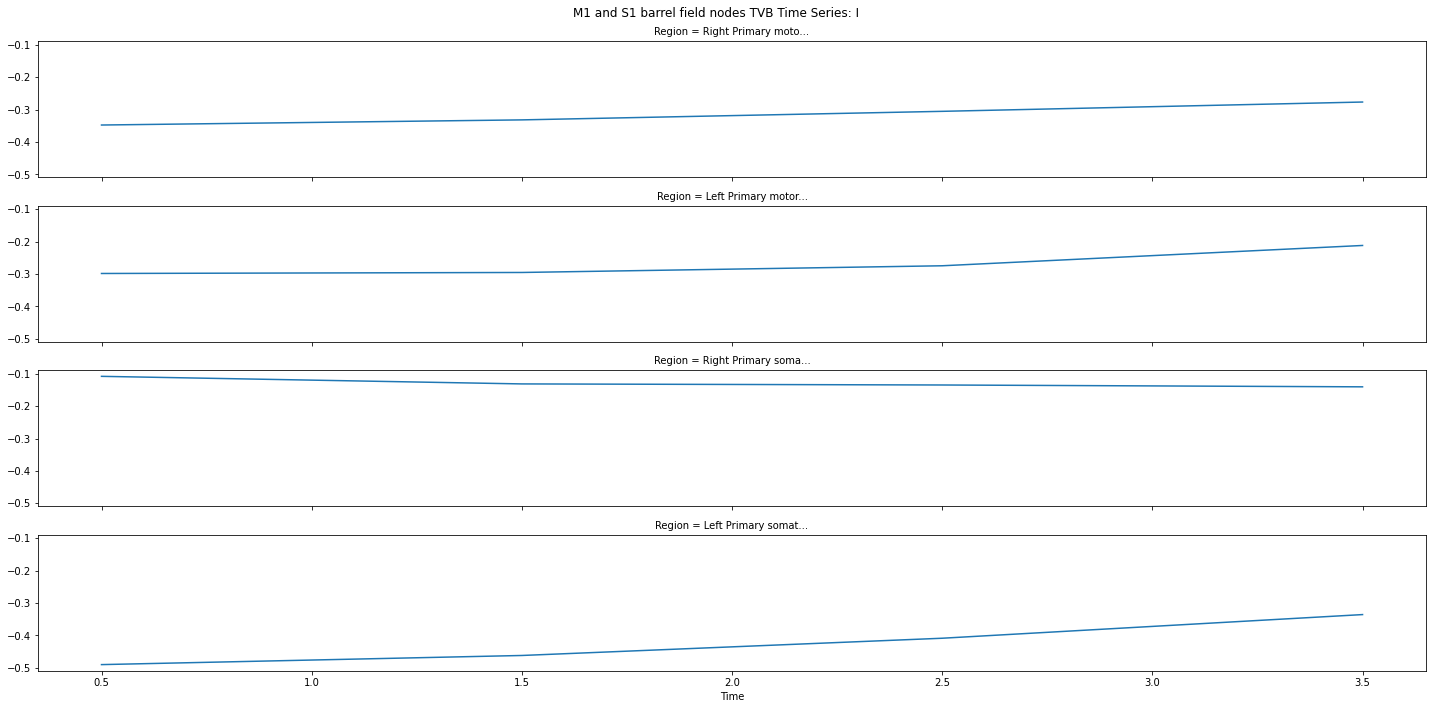

2023-10-31 18:29:33,457 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:33,459 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


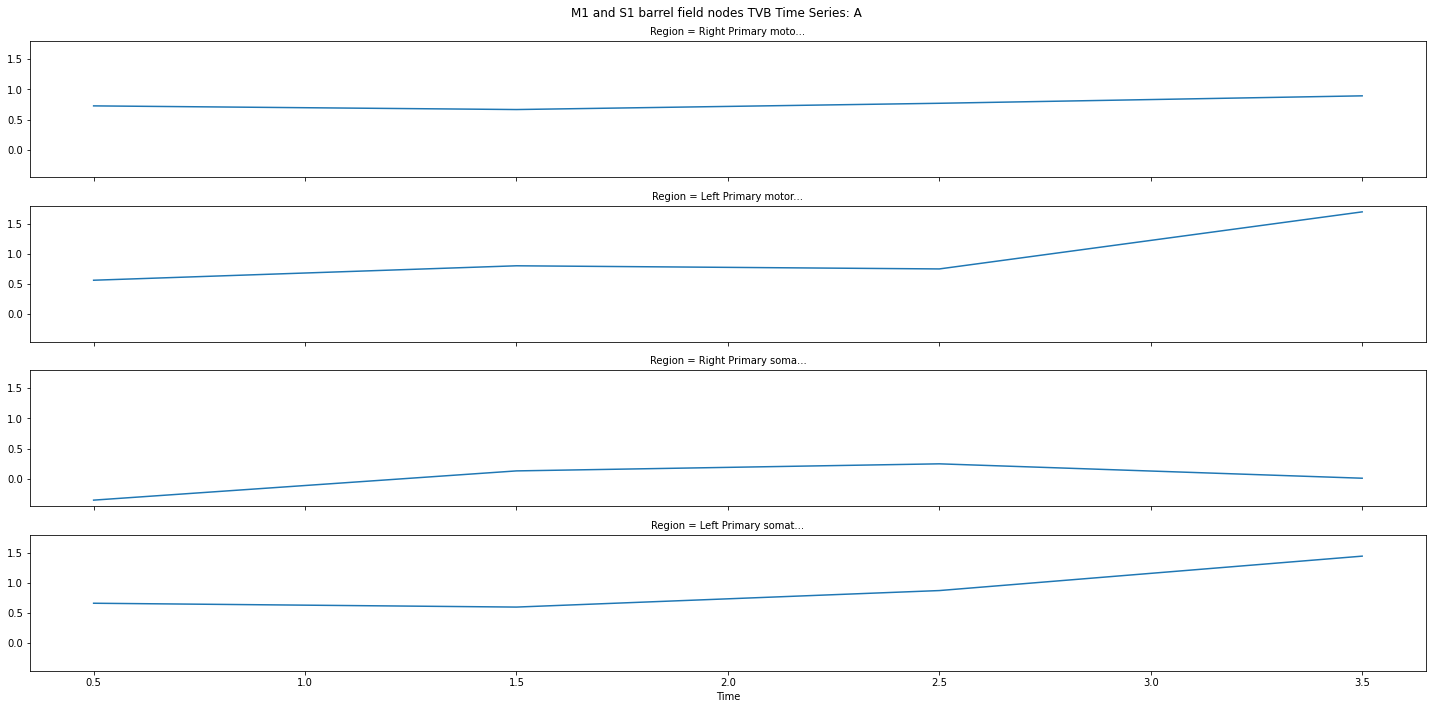

2023-10-31 18:29:34,270 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:34,273 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!
2023-10-31 18:29:34,282 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:34,284 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


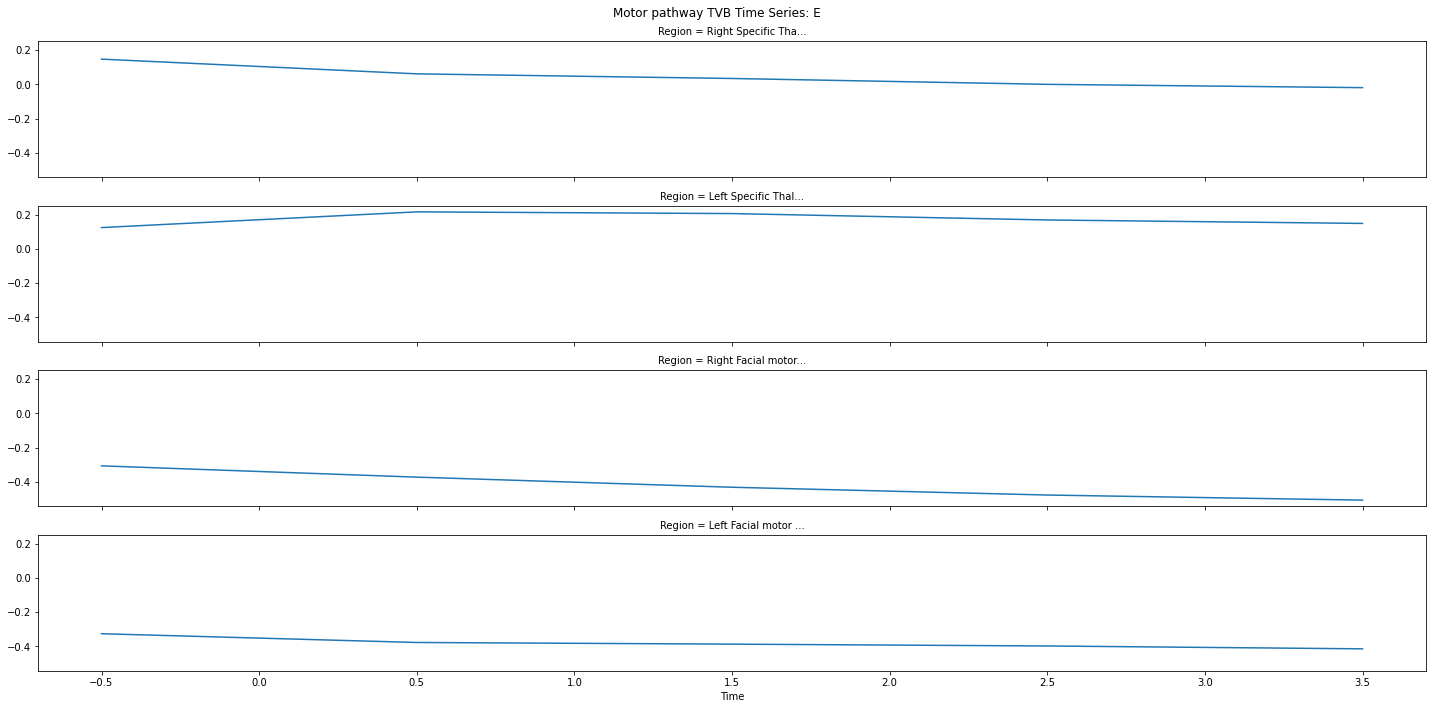

2023-10-31 18:29:35,110 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:35,111 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


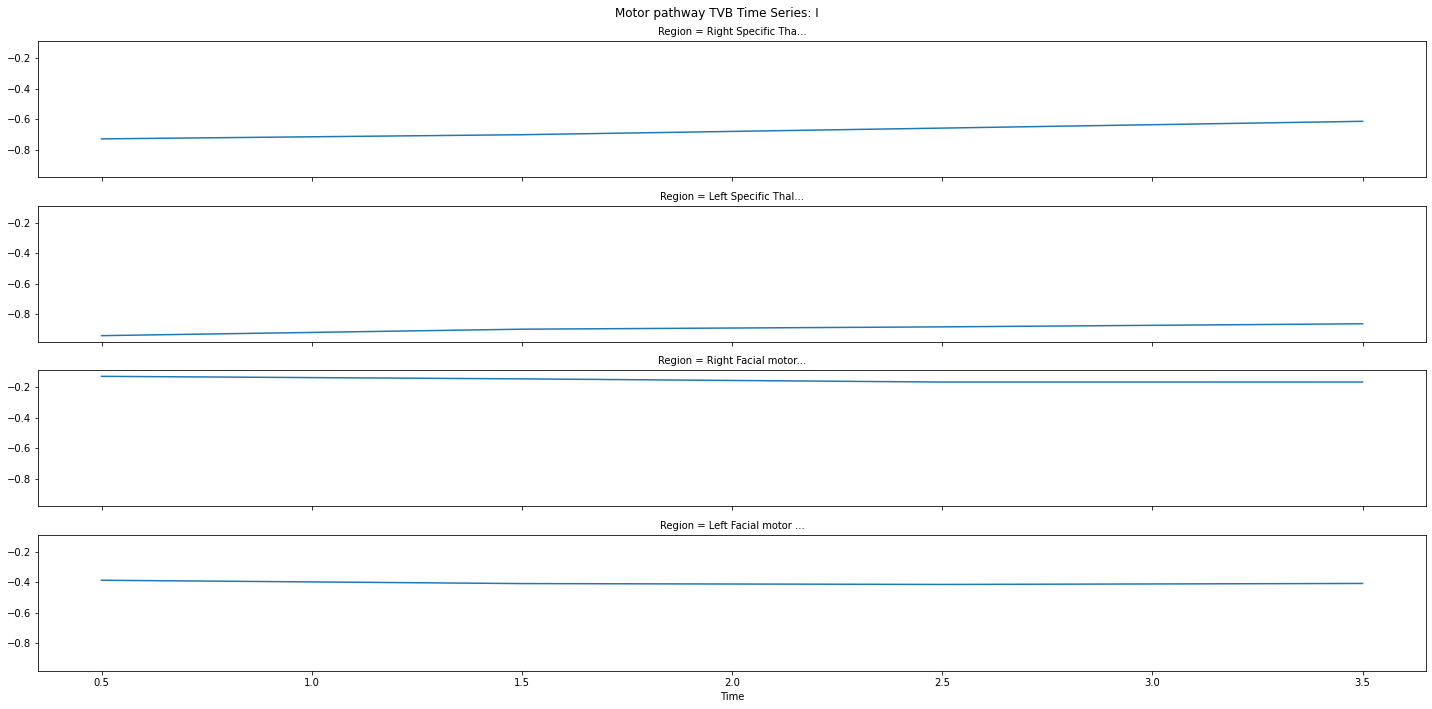

2023-10-31 18:29:35,815 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:35,816 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


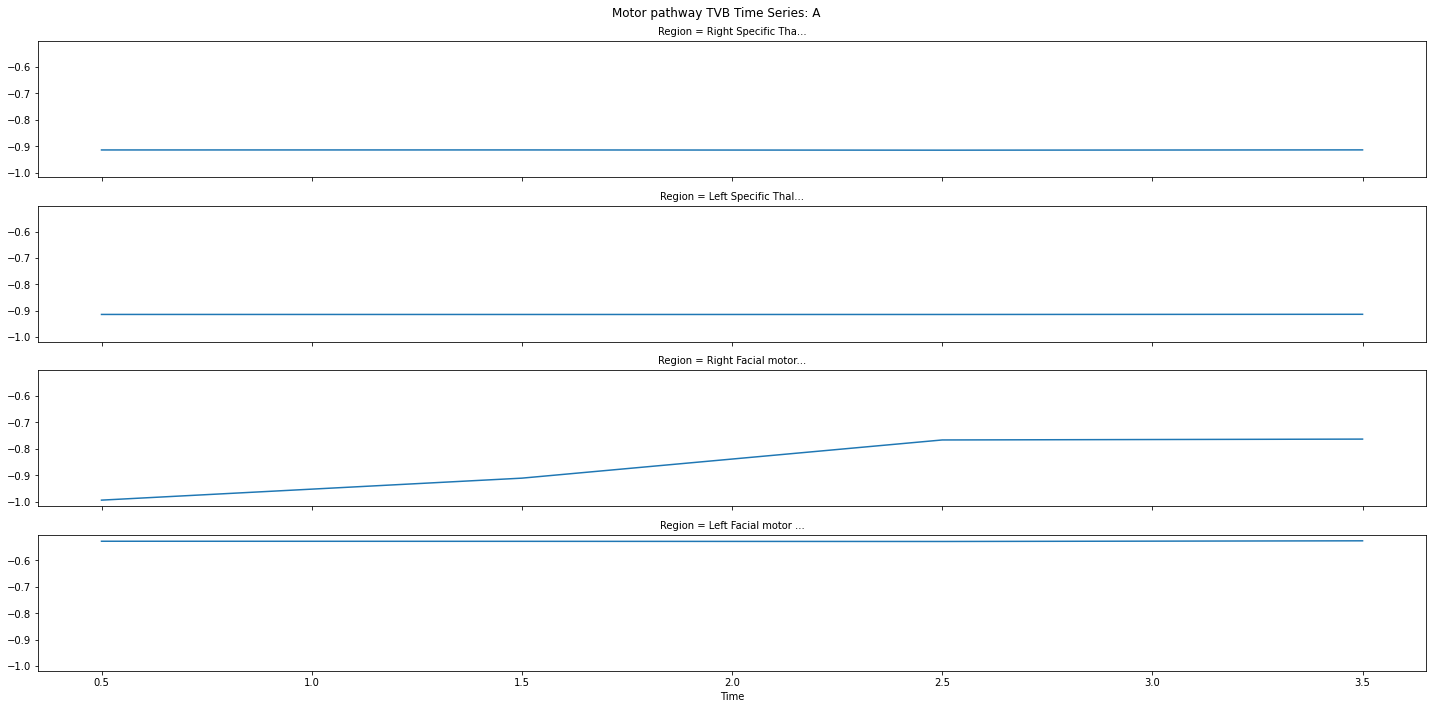

2023-10-31 18:29:36,449 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:36,450 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!
2023-10-31 18:29:36,454 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:36,455 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


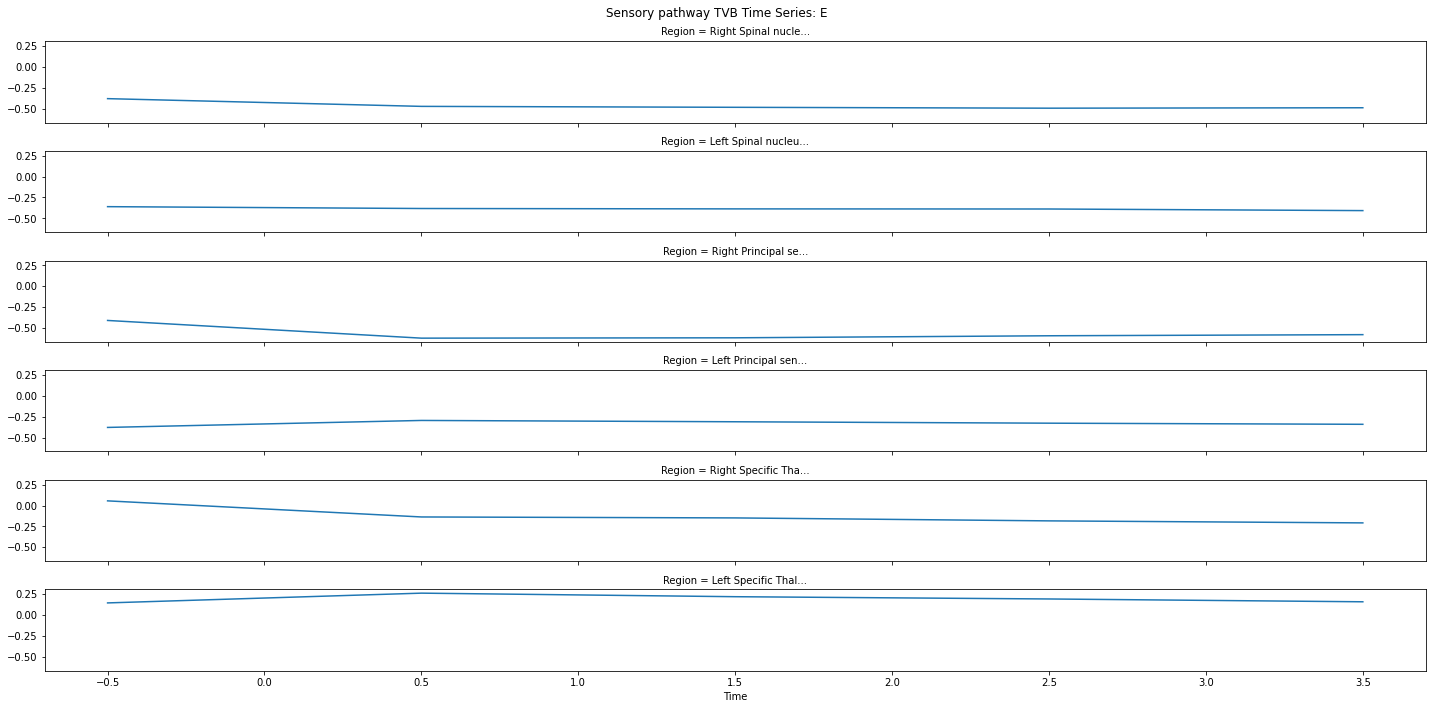

2023-10-31 18:29:37,279 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:37,279 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


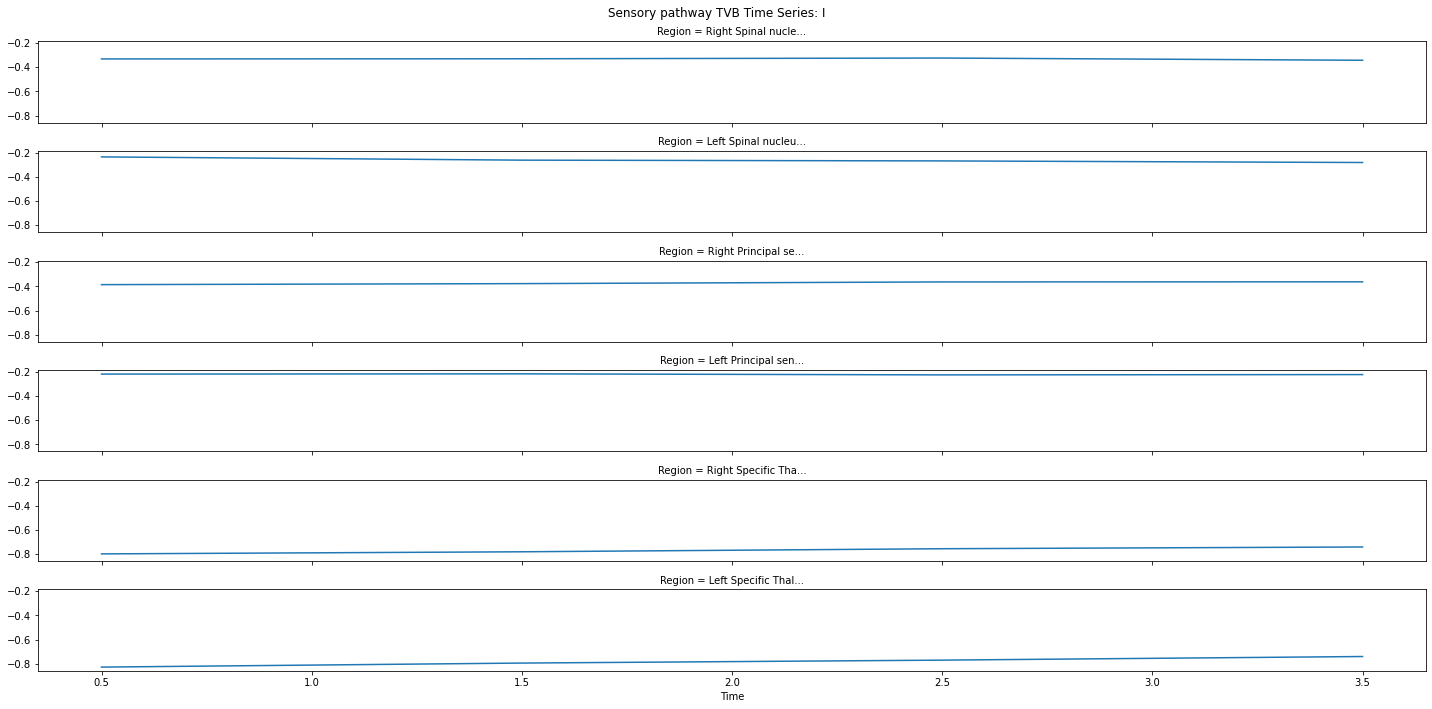

2023-10-31 18:29:38,077 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:38,078 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


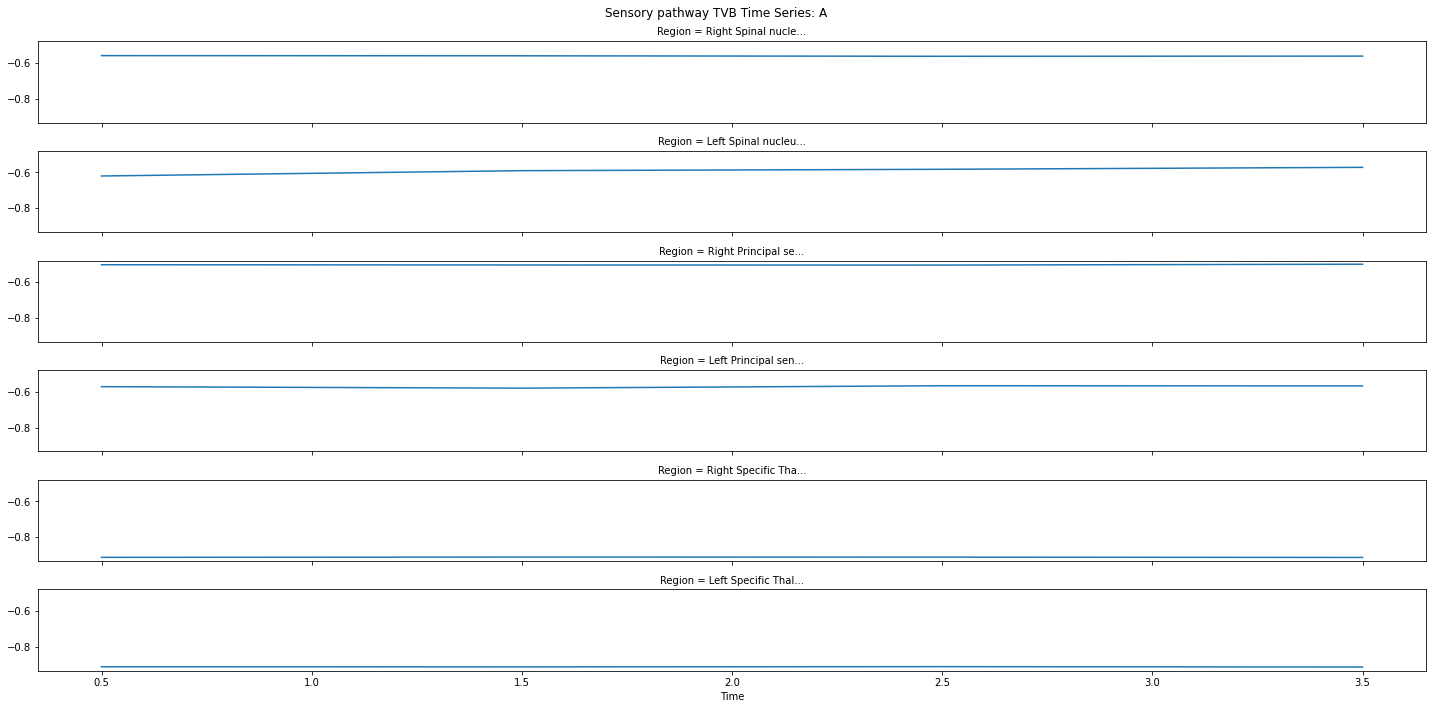

2023-10-31 18:29:39,034 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:39,035 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!
2023-10-31 18:29:39,038 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:39,039 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


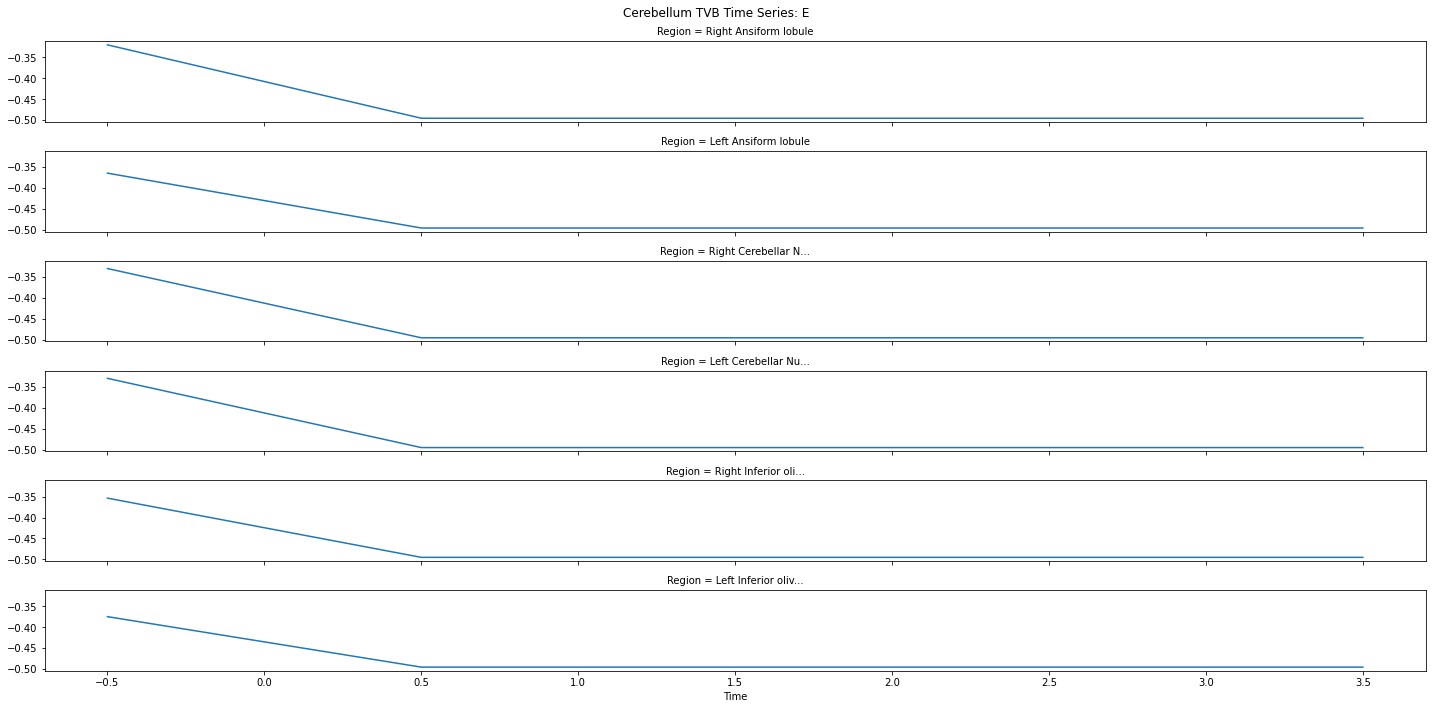

2023-10-31 18:29:39,864 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:39,865 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


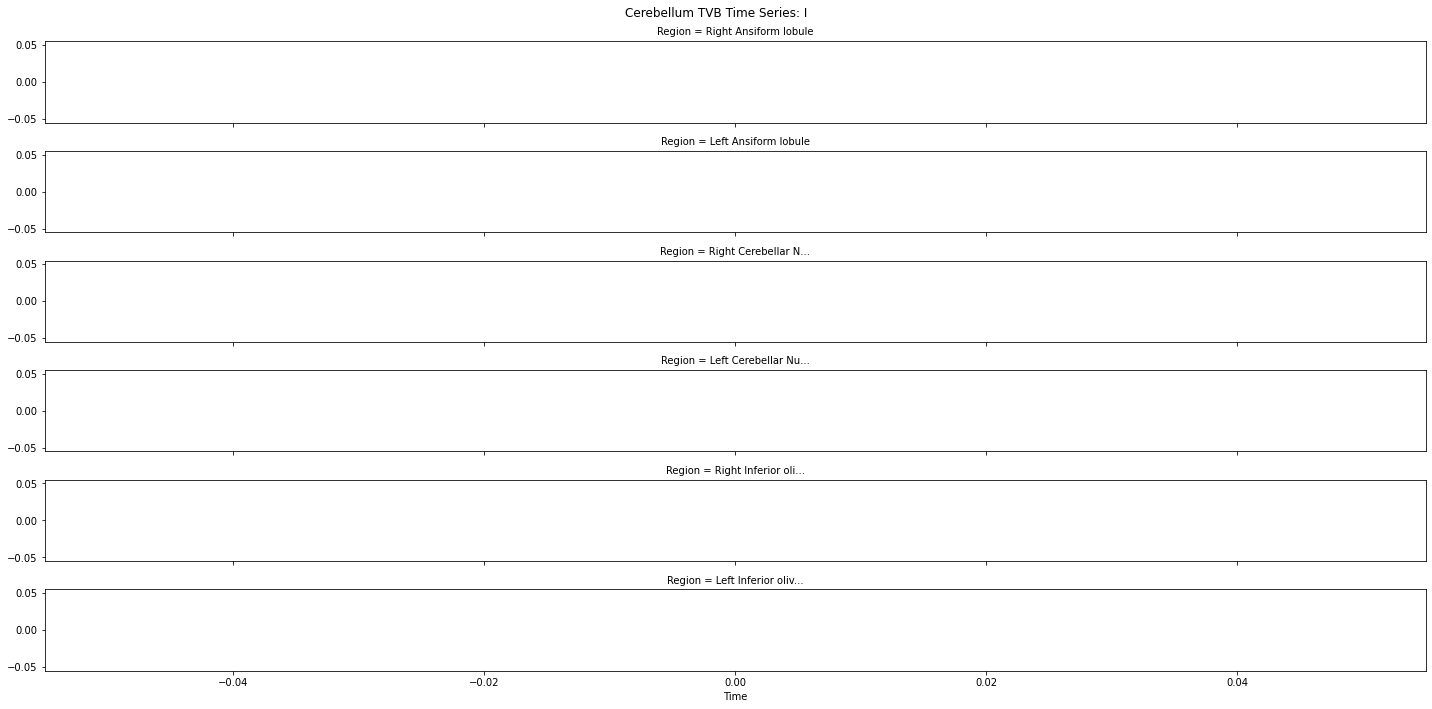

2023-10-31 18:29:40,653 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:40,655 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


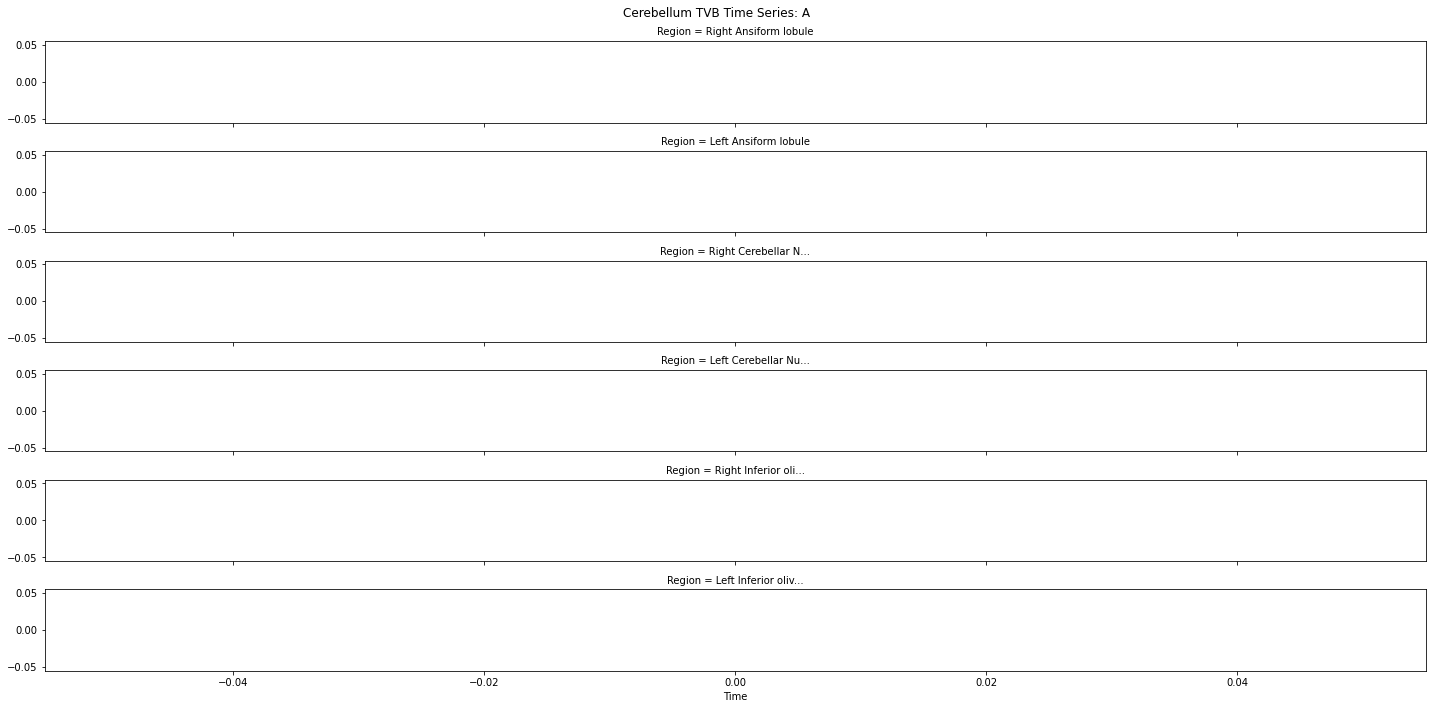

2023-10-31 18:29:41,592 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:41,593 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


/home/docker/env/neurosci/lib/python3.9/site-packages/scipy/signal/_spectral_py.py:1961: UserWarning:nperseg = 512 is greater than input length  = 4, using nperseg = 4


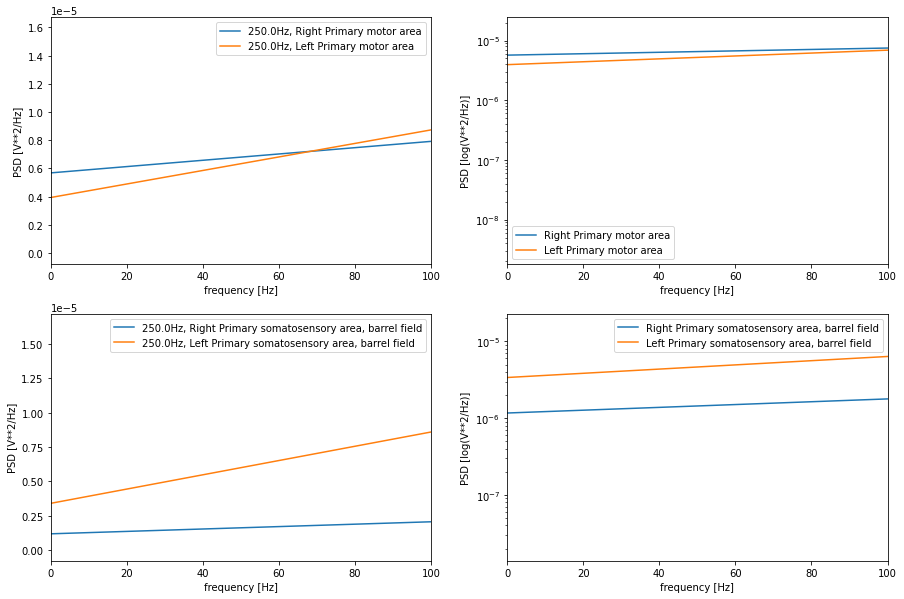

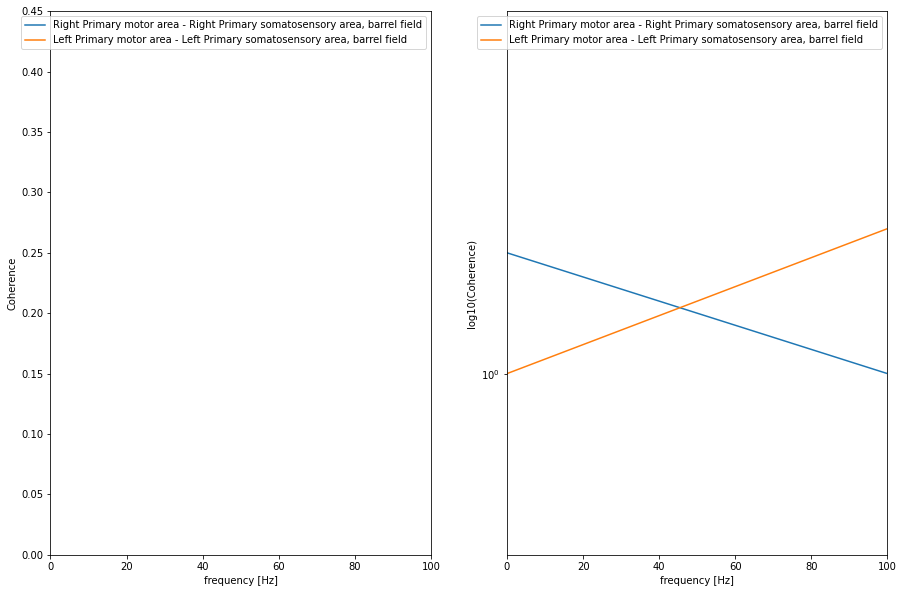

2023-10-31 18:29:43,520 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:43,521 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


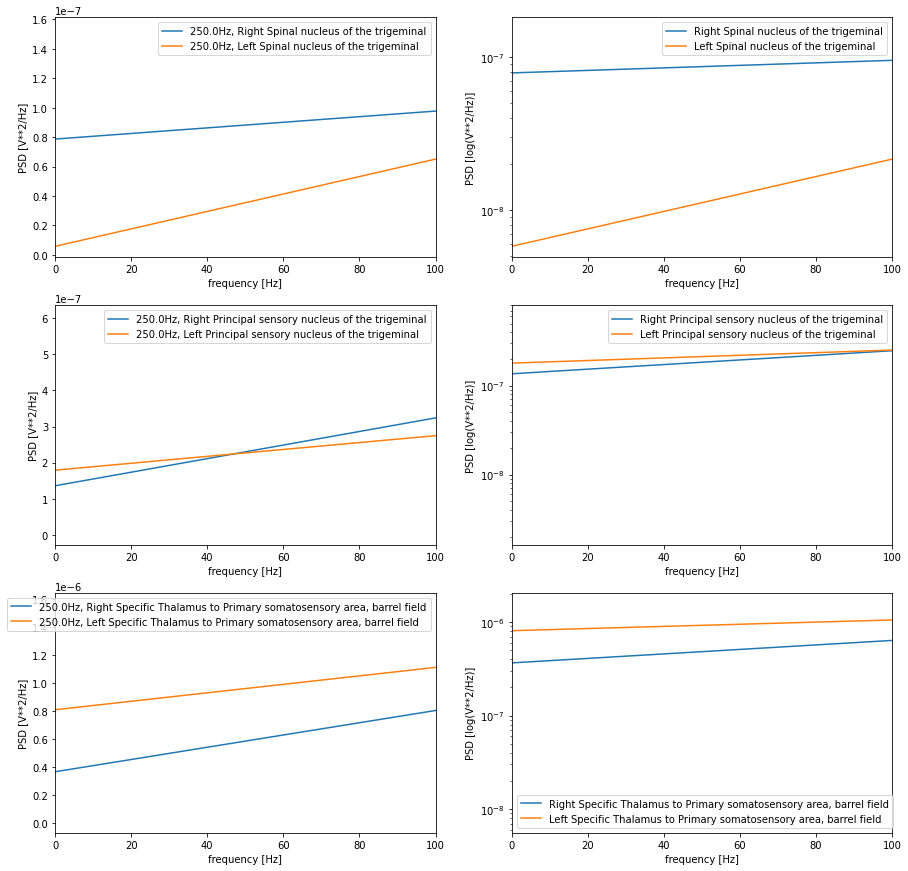

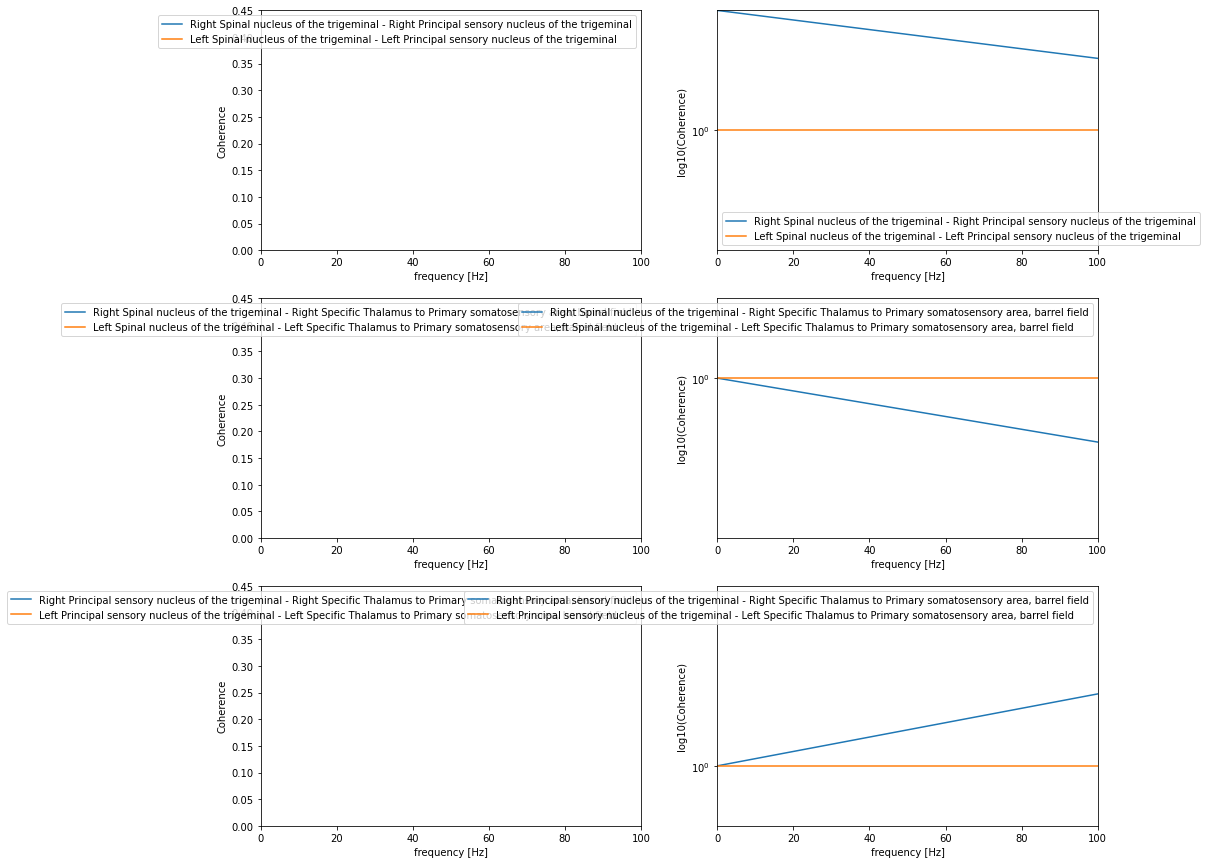

psd input cereb!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
inds ansilob [104 210]
Ansiform lobule source_ts PSD, with compute_plot_selected_spectra_coherence
2023-10-31 18:29:47,316 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:47,317 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


/home/docker/packages/tvb-multiscale/rising_net/utils.py:96: UserWarning:Data has no positive values, and therefore cannot be log-scaled.


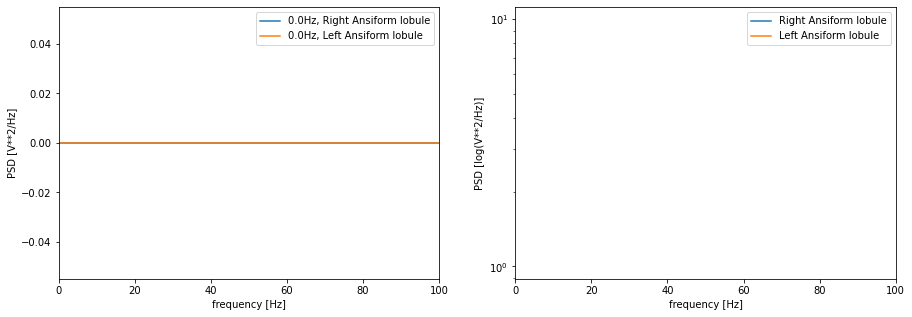

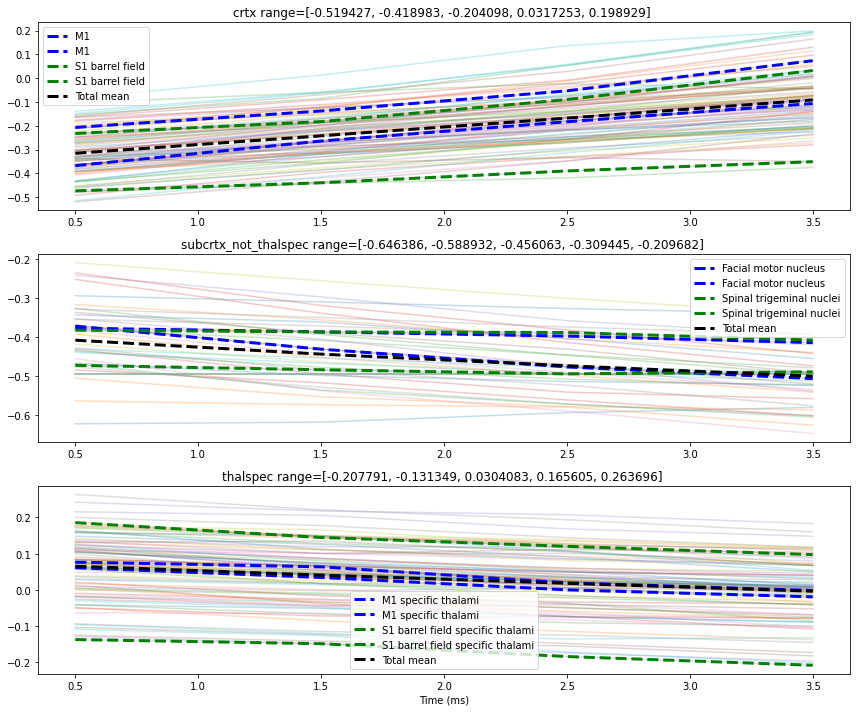

2023-10-31 18:29:49,768 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:49,770 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


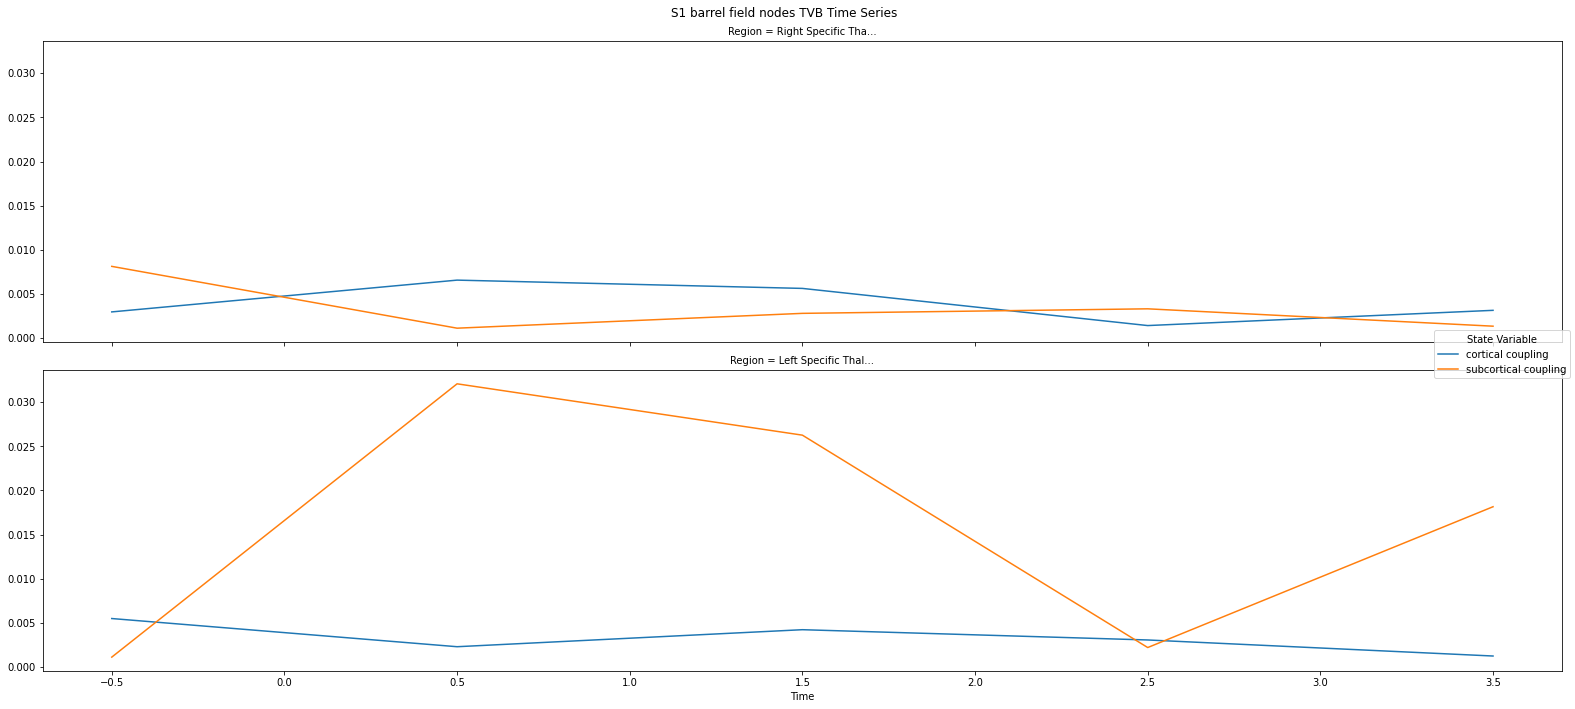

2023-10-31 18:29:50,704 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:50,705 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


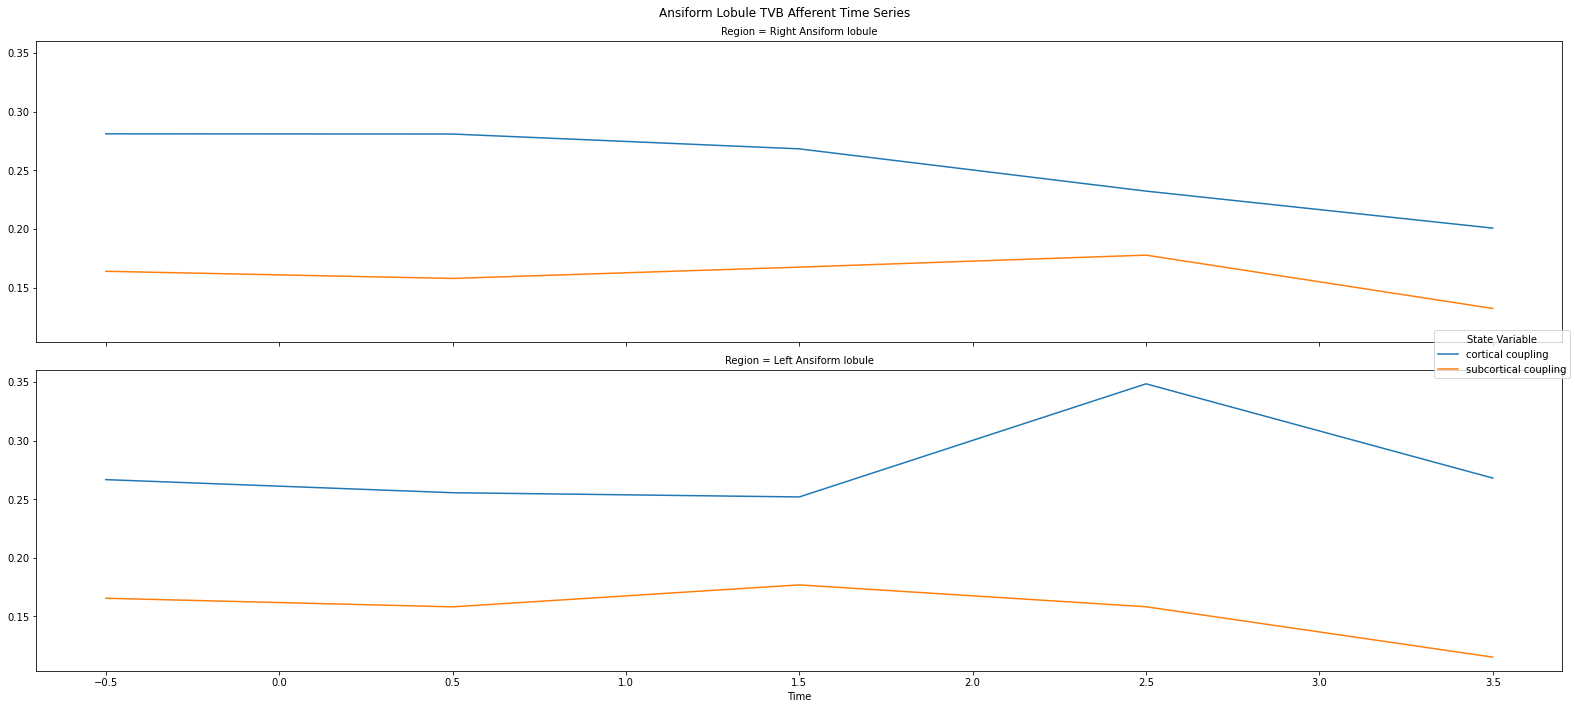

Ansiform lobule afferent PSD, with compute_plot_selected_spectra_coherence
2023-10-31 18:29:51,454 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:51,454 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


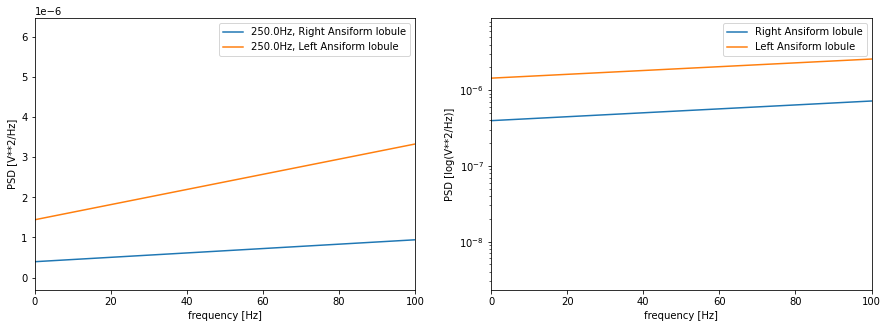

2023-10-31 18:29:52,112 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - 'NoneType' object is not subscriptable
2023-10-31 18:29:52,113 - WARNING - tvb.contrib.scripts.datatypes.time_series_xarray - Connectivity and RegionTimeSeries labels agreement failed!


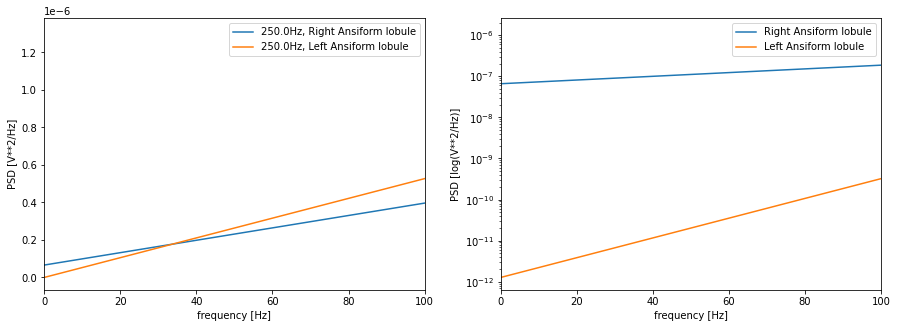

In [3]:
import pickle
results_path = os.path.join(config.FOLDER_RES, + '%s.pickle' % resfilename)
with open(results_path, 'wb') as handle:
   pickle.dump(results, handle)
print(results_path)
# results = pickle.load(results_path, 'rb'))  # to load results

In [4]:
cohfilename = "coherence_30sec_%s_noise_seed_%d" % (test_name, seed)
coherence_path = os.path.join(config.FOLDER_RES, + '%s.pickle' % cohfilename)
# Save coherence
CxyR = results["CxyR_M1_S1"]
fR = results["fR"]
CxyL = results["Cxyl_M1_S1"]
fL = results["fL"]
with open(coherence_path, 'wb') as handle:
    pickle.dump([CxyR, fR, fL, CxyL], handle)
print(coherence_path)